<a href="https://colab.research.google.com/github/YUCAVALCANTE/ML_Studies/blob/main/Exercicio_Pos_UNICAMP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Carregar e explorar os dados**

Nesta primeira etapa, o objetivo é importar as bibliotecas necessárias, carregar o arquivo CSV no Google Colab e fazer uma exploração inicial da base.

Essa exploração ajuda a entender a estrutura dos dados, os tipos de colunas, a presença de valores nulos e algumas inconsistências iniciais, como variações no campo de estado.

In [36]:
# ==========================================
# 1. Carregar e explorar os dados
# ==========================================

import pandas as pd
import numpy as np
import re
import unicodedata

df = pd.read_csv('/content/sample_data/atividade7_enderecos_entrega.csv')
display(df.head())

df.info()

display(df.describe(include='all'))

display(df['estado'].value_counts(dropna=False))

,id_endereco,id_cliente,cep,logradouro,numero,complemento,bairro,cidade,estado,pais,tipo_endereco
0,1,84,04616143,Av. das Flores,SN,AP 101,VILA NOVA,UBERLANDIA,MINAS GERAIS,brasil,comercial
1,2,108,00000-000,RUA 7 de Setembro,s/n,BLOCO A,VILA NOVA,Porto Alegre,Rio Grande do Sul,br,comercial
2,3,42,88231 329,Al. PRINCIPAL,8385 A,CASA,Jardim América,Uberlândia,M.G.,BRA,comercial
3,4,149,19776385,ALAMEDA 7 de Setembro,2426-A,Sala 10,JARDIM AMERICA,CURITIBA,Parana,BRA,Entrega
4,5,108,99999-999,Al. SAO PAULO,S/N,Sala 10,Vila Nova,RIO DE JANEIRO,R.J.,brasil,comercial


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id_endereco    400 non-null    int64 
 1   id_cliente     400 non-null    int64 
 2   cep            375 non-null    object
 3   logradouro     400 non-null    object
 4   numero         368 non-null    object
 5   complemento    342 non-null    object
 6   bairro         314 non-null    object
 7   cidade         400 non-null    object
 8   estado         400 non-null    object
 9   pais           341 non-null    object
 10  tipo_endereco  352 non-null    object
dtypes: int64(2), object(9)
memory usage: 34.5+ KB


,id_endereco,id_cliente,cep,logradouro,numero,complemento,bairro,cidade,estado,pais,tipo_endereco
count,400.000000,400.00000,375,400,368,342,314,400,400,341,352
unique,NaN,NaN,334,156,228,13,7,25,29,6,8
top,NaN,NaN,00000-000,avenida das Flores,s/n,CASA,CENTRO,CURITIBA,SP,BR,Entrega
freq,NaN,NaN,25,6,49,35,53,21,22,65,56
mean,200.500000,103.45750,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,115.614301,54.93736,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,2.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,100.750000,55.75000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,200.500000,101.50000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,300.250000,152.25000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,count
estado,
SP,22
MG,21
rs,20
SAO PAULO,19
MINAS GERAIS,17
Rio Grande do Sul,17
RJ,16
R.S.,16
RS,16


**2. Criar as funções de limpeza**

Nesta etapa, o objetivo é definir funções para padronizar os campos do endereço conforme os critérios da atividade.
Cada função trata um campo específico, como CEP, logradouro, número, complemento, cidade, estado e país.
A ideia é garantir que os dados fiquem consistentes antes da análise e da exportação do arquivo final.

In [37]:
# ==========================================
# 2. Criar as funções de limpeza
# ==========================================

# Remove acentos e caracteres especiais de textos
def remover_acentos(texto):
    if pd.isna(texto):
        return texto
    return ''.join(
        c for c in unicodedata.normalize('NFKD', str(texto))
        if not unicodedata.combining(c)
    )


# Padroniza o CEP: mantém apenas números e valida se possui 8 dígitos
def limpar_cep(cep):
    if pd.isna(cep):
        return np.nan

    cep = re.sub(r'\D', '', str(cep))

    if len(cep) == 8:
        return cep
    return np.nan


# Padroniza o logradouro: expande abreviações e converte para Title Case
def limpar_logradouro(log):
    if pd.isna(log):
        return log

    log = str(log).strip().lower()

    log = log.replace('r.', 'rua ')
    log = log.replace('rua', 'rua')
    log = log.replace('av.', 'avenida ')
    log = log.replace('av ', 'avenida ')

    log = re.sub(r'\s+', ' ', log).strip()

    return log.title()


# Mantém apenas o número principal do endereço
def limpar_numero(num):
    if pd.isna(num):
        return np.nan

    num = str(num)
    match = re.search(r'\d+', num)

    if match:
        return match.group()
    return np.nan


# Padroniza o complemento: expande abreviações e converte para Title Case
def limpar_complemento(comp):
    if pd.isna(comp):
        return comp

    comp = str(comp).lower()

    comp = comp.replace('apto', 'apartamento')
    comp = comp.replace('ap.', 'apartamento')
    comp = comp.replace('bl.', 'bloco')

    comp = re.sub(r'\s+', ' ', comp).strip()

    return comp.title()


# Padroniza a cidade: remove acentos e converte para maiúsculas
def limpar_cidade(cidade):
    if pd.isna(cidade):
        return cidade

    cidade = remover_acentos(str(cidade))
    return cidade.upper().strip()


# Base oficial de estados para converter nomes e siglas em formato padrão
base_estados = {
    'ACRE': 'AC',
    'ALAGOAS': 'AL',
    'AMAPA': 'AP',
    'AMAZONAS': 'AM',
    'BAHIA': 'BA',
    'CEARA': 'CE',
    'DISTRITO FEDERAL': 'DF',
    'ESPIRITO SANTO': 'ES',
    'GOIAS': 'GO',
    'MARANHAO': 'MA',
    'MATO GROSSO': 'MT',
    'MATO GROSSO DO SUL': 'MS',
    'MINAS GERAIS': 'MG',
    'PARA': 'PA',
    'PARAIBA': 'PB',
    'PARANA': 'PR',
    'PERNAMBUCO': 'PE',
    'PIAUI': 'PI',
    'RIO DE JANEIRO': 'RJ',
    'RIO GRANDE DO NORTE': 'RN',
    'RIO GRANDE DO SUL': 'RS',
    'RONDONIA': 'RO',
    'RORAIMA': 'RR',
    'SANTA CATARINA': 'SC',
    'SAO PAULO': 'SP',
    'SERGIPE': 'SE',
    'TOCANTINS': 'TO'
}

siglas_validas = set(base_estados.values())


# Normaliza o texto bruto do estado antes da padronização
def normalizar_estado_bruto(estado):
    if pd.isna(estado):
        return np.nan

    estado = remover_acentos(estado).upper().strip()
    estado = re.sub(r'[^A-Z\s]', ' ', estado)
    estado = re.sub(r'\s+', ' ', estado).strip()

    return estado


# Padroniza o estado de forma automática, convertendo para sigla oficial
def limpar_estado(estado):
    if pd.isna(estado):
        return np.nan

    estado_norm = normalizar_estado_bruto(estado)

    if pd.isna(estado_norm) or estado_norm == '':
        return np.nan

    # Caso seja sigla escrita com espaço, como "S P"
    estado_sigla = estado_norm.replace(' ', '')
    if len(estado_sigla) == 2 and estado_sigla in siglas_validas:
        return estado_sigla

    # Caso seja nome completo
    if estado_norm in base_estados:
        return base_estados[estado_norm]

    return np.nan


# Padroniza o país: preenche vazios e define sempre como Brasil
def limpar_pais(pais):
    return 'Brasil'

**3. Aplicar as funções de limpeza e validar os dados**

Nesta etapa, o objetivo é aplicar todas as funções de limpeza no DataFrame, garantindo que os dados estejam padronizados conforme os critérios definidos.

Em seguida, realizamos uma validação básica para confirmar se a limpeza foi aplicada corretamente.

In [38]:
# ==========================================
# 3. Aplicar as funções de limpeza
# ==========================================

df['cep'] = df['cep'].apply(limpar_cep)
df['logradouro'] = df['logradouro'].apply(limpar_logradouro)
df['numero'] = df['numero'].apply(limpar_numero)
df['complemento'] = df['complemento'].apply(limpar_complemento)
df['cidade'] = df['cidade'].apply(limpar_cidade)
df['estado'] = df['estado'].apply(limpar_estado)
df['pais'] = df['pais'].apply(limpar_pais)

In [39]:
# Visualizar amostra dos dados tratados
display(df.head())

# Verificar valores nulos por coluna
display(df.isna().sum())

# Conferir distribuição dos estados (já padronizados)
display(df['estado'].value_counts(dropna=False))

# Verificar CEPs inválidos (nulos após limpeza)
print(f"Total de CEPs inválidos: {df['cep'].isna().sum()}")

,id_endereco,id_cliente,cep,logradouro,numero,complemento,bairro,cidade,estado,pais,tipo_endereco
0,1,84,04616143,Avenida Das Flores,NaN,Ap 101,VILA NOVA,UBERLANDIA,MG,Brasil,comercial
1,2,108,00000000,Rua 7 De Setembro,NaN,Bloco A,VILA NOVA,PORTO ALEGRE,RS,Brasil,comercial
2,3,42,88231329,Al. Principal,8385,Casa,Jardim América,UBERLANDIA,MG,Brasil,comercial
3,4,149,19776385,Alameda 7 De Setembro,2426,Sala 10,JARDIM AMERICA,CURITIBA,PR,Brasil,Entrega
4,5,108,99999999,Al. Sao Paulo,NaN,Sala 10,Vila Nova,RIO DE JANEIRO,RJ,Brasil,comercial


,0
id_endereco,0
id_cliente,0
cep,58
logradouro,0
numero,175
complemento,58
bairro,86
cidade,0
estado,0
pais,0


,count
estado,
SP,91
MG,86
PR,79
RS,78
RJ,66


Total de CEPs inválidos: 58


In [40]:
# Remove registros duplicados
df = df.drop_duplicates()

**4. Gerar os entregáveis finais**

Nesta etapa, o objetivo é gerar os outputs solicitados na atividade:

arquivo CSV com os dados padronizados

contagem de endereços por estado

lista dos CEPs inválidos identificados antes da limpeza

In [41]:
# ==========================================
# 4.1 Exportar arquivo final
# ==========================================

df.to_csv('/content/sample_data/enderecos_limpos.csv', index=False)

In [42]:
# ==========================================
# 4.2 Contagem por estado
# ==========================================

contagem_estado = df['estado'].value_counts(dropna=False)

display(contagem_estado)

,count
estado,
SP,91
MG,86
PR,79
RS,78
RJ,66


In [43]:
# ==========================================
# 4.3 CEPs inválidos
# ==========================================

df_original = pd.read_csv('/content/sample_data/atividade7_enderecos_entrega.csv')

def cep_valido(cep):
    cep = re.sub(r'\D', '', str(cep))
    return len(cep) == 8

ceps_invalidos = df_original[~df_original['cep'].apply(cep_valido)]

lista_ceps_invalidos = ceps_invalidos['cep'].head(5)

display(lista_ceps_invalidos)

print(f"Total de CEPs inválidos encontrados: {len(ceps_invalidos)}")

,cep
6,93943
13,NaN
14,NaN
23,00796
25,59099


Total de CEPs inválidos encontrados: 58


In [44]:
# ==========================================
# 4.4 Download do arquivo no Colab
# ==========================================

from google.colab import files

files.download('/content/sample_data/enderecos_limpos.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**5. Gerar gráficos para análise exploratória**

Nesta etapa, o objetivo é criar gráficos simples que ajudem a validar a qualidade dos dados após a limpeza e apoiem a interpretação dos resultados.

Foram escolhidas visualizações coerentes com o problema de negócio: distribuição geográfica, qualidade dos CEPs, concentração por cidade e completude do número do endereço.

In [45]:
# ==========================================
# 5. Gerar gráficos para análise exploratória
# ==========================================

import matplotlib.pyplot as plt

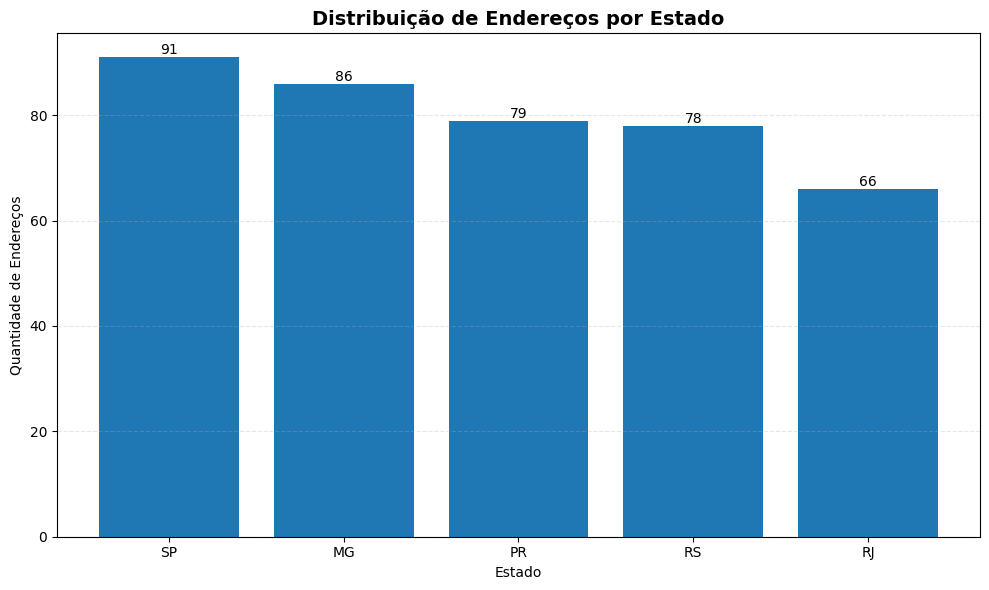

In [46]:
# ==========================================
# 5.1 Gráfico de endereços por estado
# ==========================================
contagem_estado = df['estado'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10,6))

bars = plt.bar(contagem_estado.index, contagem_estado.values)

plt.title('Distribuição de Endereços por Estado', fontsize=14, weight='bold')
plt.xlabel('Estado')
plt.ylabel('Quantidade de Endereços')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Explicação do gráfico

Este gráfico apresenta a **distribuição da quantidade de endereços por estado** após o processo de limpeza e padronização dos dados.

Observa-se que:

- **São Paulo (SP)** possui a maior quantidade de registros, com **91 endereços**, indicando a maior concentração na base.  
- Em seguida, aparecem **Minas Gerais (MG)** com **86 registros**, e **Paraná (PR)** e **Rio Grande do Sul (RS)** com valores próximos (**79 e 78**, respectivamente).  
- **Rio de Janeiro (RJ)** apresenta a menor quantidade entre os estados analisados, com **66 registros**.

- A distribuição mostra que a base está relativamente **concentrada na região Sudeste e Sul**, com destaque para São Paulo.  
- A proximidade entre alguns estados (PR e RS, por exemplo) indica uma **distribuição relativamente equilibrada**, fora o estado líder.  
- O gráfico também confirma que a **padronização dos estados foi bem-sucedida**, já que não há variações como “SP”, “S.P.” ou “São Paulo”.


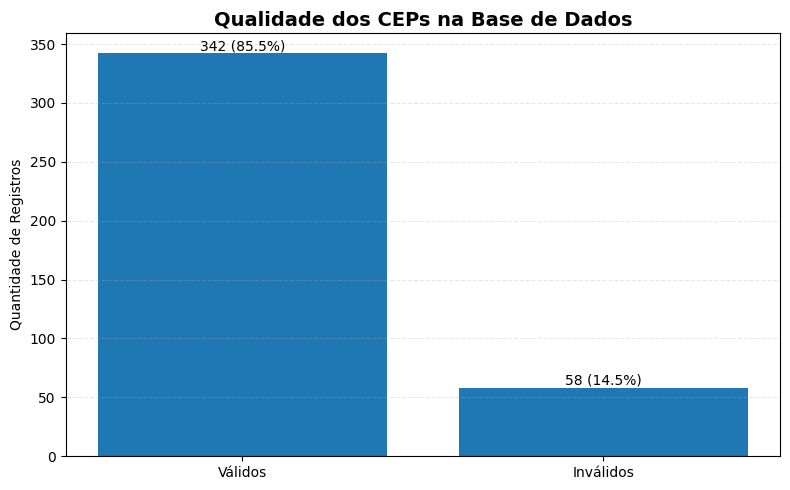

In [47]:
# ==========================================
# 5.2 Qualidade dos CEPs
# ==========================================

cep_validos = df['cep'].notna().sum()
cep_invalidos = df['cep'].isna().sum()

valores = [cep_validos, cep_invalidos]
labels = ['Válidos', 'Inválidos']

total = sum(valores)

plt.figure(figsize=(8,5))

bars = plt.bar(labels, valores)

plt.title('Qualidade dos CEPs na Base de Dados', fontsize=14, weight='bold')
plt.ylabel('Quantidade de Registros')

for i, bar in enumerate(bars):
    height = bar.get_height()
    percentual = (height / total) * 100

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)} ({percentual:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## Explicação do gráfico

Este gráfico apresenta a **qualidade dos CEPs na base de dados** após o processo de limpeza e padronização.

Observa-se que:

- A grande maioria dos registros possui CEP **válido**, totalizando **342 registros (85,5%)**.  
- Já os CEPs **inválidos** somam **58 registros (14,5%)**, sendo aqueles que não atendem ao critério de possuir exatamente 8 dígitos numéricos.

- A base apresenta uma **boa qualidade geral no campo CEP**, com mais de 80% dos registros válidos.  
- A existência de CEPs inválidos indica a presença de **inconsistências na origem dos dados**, como preenchimento incorreto ou formatos inadequados.  
- O processo de limpeza foi essencial para garantir que apenas CEPs válidos sejam considerados em análises futuras.


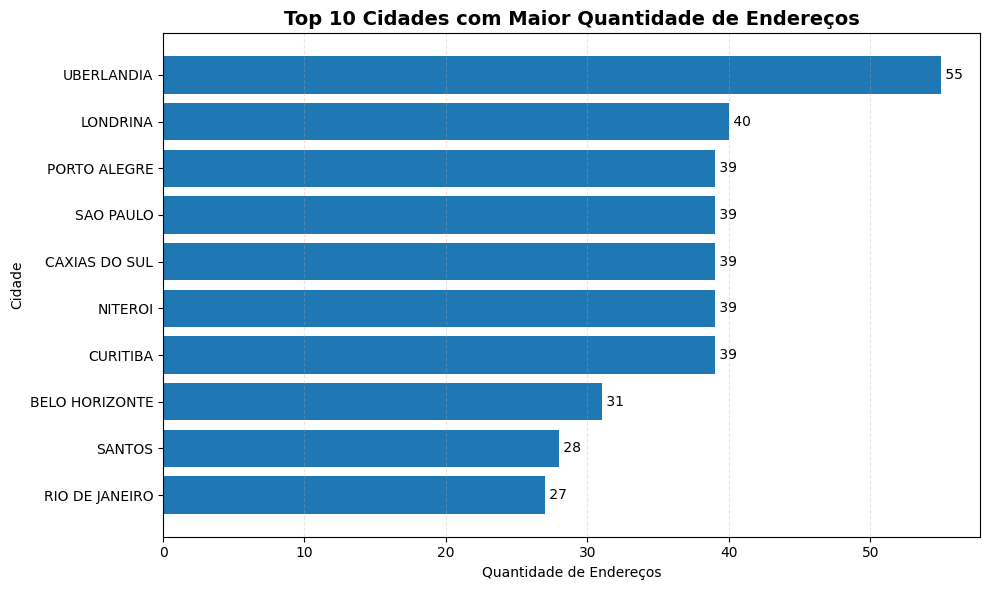

In [48]:
# ==========================================
# 5.3 Top 10 cidades com mais registros
# ==========================================

top_cidades = df['cidade'].value_counts().head(10).sort_values(ascending=True)

plt.figure(figsize=(10,6))

bars = plt.barh(top_cidades.index, top_cidades.values)

plt.title('Top 10 Cidades com Maior Quantidade de Endereços', fontsize=14, weight='bold')
plt.xlabel('Quantidade de Endereços')
plt.ylabel('Cidade')

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f' {int(width)}',
        va='center',
        fontsize=10
    )

plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## Explicação do gráfico

Este gráfico apresenta as **10 cidades com maior quantidade de endereços** na base de dados após o processo de limpeza e padronização.

Observa-se que:

- **Uberlândia** lidera com **55 registros**, sendo a cidade com maior concentração de endereços.  
- Em seguida, aparecem **Londrina (40)** e um grupo de cidades com valores muito próximos (**39 registros**), incluindo Porto Alegre, São Paulo, Caxias do Sul, Niterói e Curitiba.  
- Outras cidades relevantes são **Belo Horizonte (31)**, **Santos (28)** e **Rio de Janeiro (27)**.

- A distribuição indica uma **concentração relevante em algumas cidades específicas**, com destaque para Uberlândia.  
- A presença de várias cidades com valores iguais ou próximos sugere uma **distribuição relativamente equilibrada entre centros urbanos importantes**.  
- O gráfico também evidencia que os dados estão bem padronizados, permitindo uma comparação consistente entre cidades.


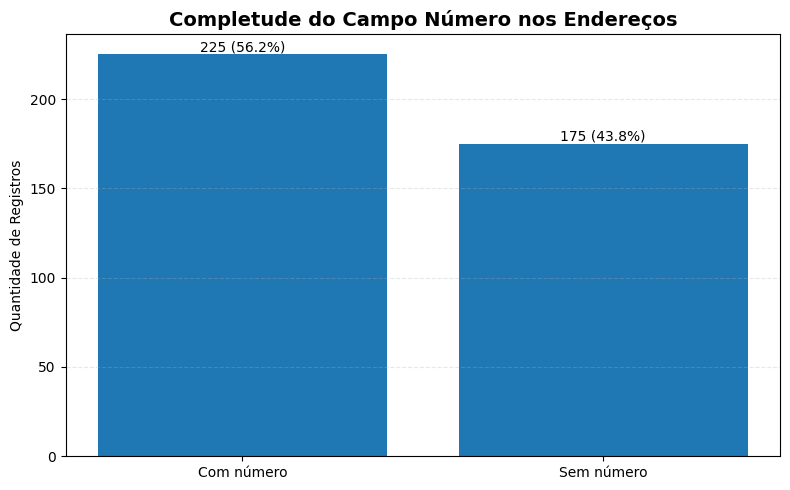

In [49]:
# ==========================================
# 5.4 Completude do campo número
# ==========================================

com_numero = df['numero'].notna().sum()
sem_numero = df['numero'].isna().sum()

valores = [com_numero, sem_numero]
labels = ['Com número', 'Sem número']

total = sum(valores)

plt.figure(figsize=(8,5))

bars = plt.bar(labels, valores)

plt.title('Completude do Campo Número nos Endereços', fontsize=14, weight='bold')
plt.ylabel('Quantidade de Registros')

for i, bar in enumerate(bars):
    height = bar.get_height()
    percentual = (height / total) * 100

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)} ({percentual:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## Explicação do gráfico

Este gráfico apresenta a **completude do campo número nos endereços** após o processo de limpeza e padronização dos dados.

Observa-se que:

- **225 registros (56,2%)** possuem número identificado, representando a maioria da base.  
- **175 registros (43,8%)** não possuem número, indicando uma parcela significativa de endereços incompletos.

- Apesar de a maioria dos endereços possuir número, a proporção de registros sem essa informação ainda é relevante.  
- A ausência do número pode indicar **problemas de preenchimento na origem dos dados** ou informações incompletas.  
- Esse tipo de inconsistência pode impactar diretamente processos como **geolocalização, roteirização e entregas**.
